<>:73: SyntaxWarning: invalid escape sequence '\l'
<>:74: SyntaxWarning: invalid escape sequence '\l'
<>:73: SyntaxWarning: invalid escape sequence '\l'
<>:74: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3512/1856474262.py:73: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("$\log_2$ Fold Change (Fold)", fontsize=12)
/tmp/ipykernel_3512/1856474262.py:74: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("$-\log_{10}$ FDR", fontsize=12)


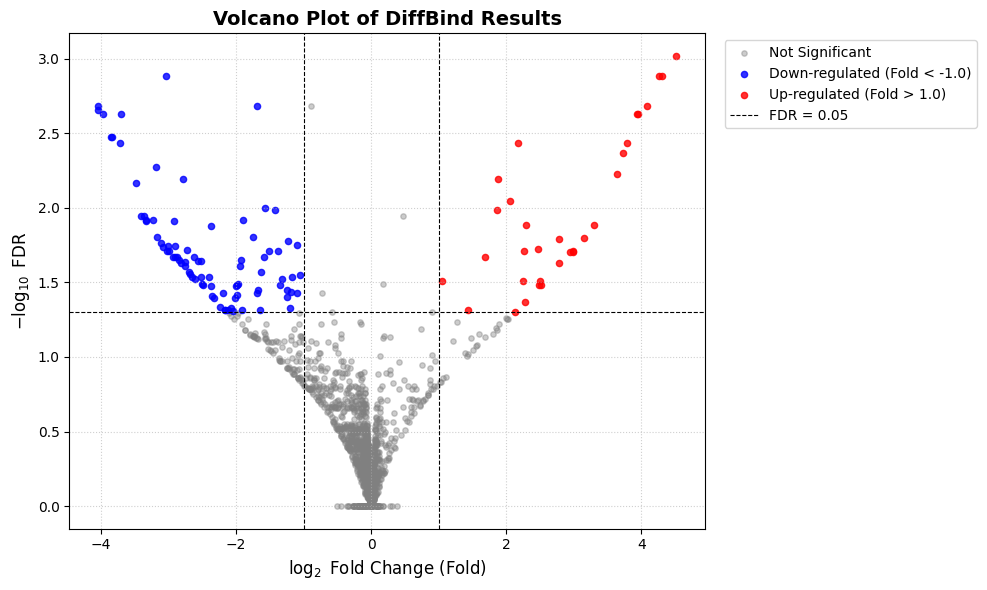

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load the DiffBind results file
file_name = "DiffBind result.csv"
df = pd.read_csv(file_name)

# 2. Calculate -log10(FDR) for the Y-axis
df["-log10_FDR"] = -np.log10(df["FDR"])

# 3. Define significance thresholds
fdr_threshold = 0.05
fold_threshold = 1.0

# Define color categories
df["color"] = "grey"  # Default: Not significant
df.loc[
    (df["Fold"] > fold_threshold) & (df["FDR"] < fdr_threshold), "color"
] = "red"  # Significantly Up
df.loc[
    (df["Fold"] < -fold_threshold) & (df["FDR"] < fdr_threshold), "color"
] = "blue"  # Significantly Down

# 4. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot non-significant points
not_sig = df[df["color"] == "grey"]
ax.scatter(
    not_sig["Fold"],
    not_sig["-log10_FDR"],
    color="grey",
    alpha=0.4,
    s=15,
    label="Not Significant",
)

# Plot significantly down-regulated points
down_reg = df[df["color"] == "blue"]
ax.scatter(
    down_reg["Fold"],
    down_reg["-log10_FDR"],
    color="blue",
    alpha=0.8,
    s=20,
    label=f"Down-regulated (Fold < -{fold_threshold})",
)

# Plot significantly up-regulated points
up_reg = df[df["color"] == "red"]
ax.scatter(
    up_reg["Fold"],
    up_reg["-log10_FDR"],
    color="red",
    alpha=0.8,
    s=20,
    label=f"Up-regulated (Fold > {fold_threshold})",
)

# 5. Add threshold lines
ax.axhline(
    -np.log10(fdr_threshold),
    color="black",
    linestyle="--",
    linewidth=0.8,
    label=f"FDR = {fdr_threshold}",
)
ax.axvline(fold_threshold, color="black", linestyle="--", linewidth=0.8)
ax.axvline(-fold_threshold, color="black", linestyle="--", linewidth=0.8)

# 6. Customize labels, title, and grid
ax.set_xlabel("$\log_2$ Fold Change (Fold)", fontsize=12)
ax.set_ylabel("$-\log_{10}$ FDR", fontsize=12)
ax.set_title("Volcano Plot of DiffBind Results", fontsize=14, fontweight="bold")

# 7. Position legend
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("volcano_plot_fixed_legend.png", dpi=300)